In [1]:
import matplotlib.pyplot as plt

from segmentation_project.data.loader import ImageLoader
from segmentation_project.preprocessing.preprocessing import RGBConverter, Sharpen
from segmentation_project.segmentation_models.yolo_segmenter import YoloSegmenter

In [2]:
# Load YOLO model
model = YoloSegmenter.load_model()

# Define image path
# image_path = "images/test_yolov8/cars-3819225_1280.jpg"


loader = ImageLoader()

image_path = loader.project_root / "images" / "test_yolov8" / "wadenswil.png"

In [3]:
# Run segmentation
results = YoloSegmenter.predict(
    model=model,
    image_path=image_path,
    conf=0.5,
)

# Render prediction output
rendered = YoloSegmenter.render_result(results)

# Convert BGR image to RGB
rendered_rgb = RGBConverter.apply(rendered)

# Sharpen the image
sharpened_image = Sharpen.apply(rendered_rgb)


image 1/1 c:\Users\Cactus\developing_software_as_product\images\test_yolov8\wadenswil.png: 448x640 4 cars, 1257.0ms
Speed: 149.3ms preprocess, 1257.0ms inference, 225.9ms postprocess per image at shape (1, 3, 448, 640)


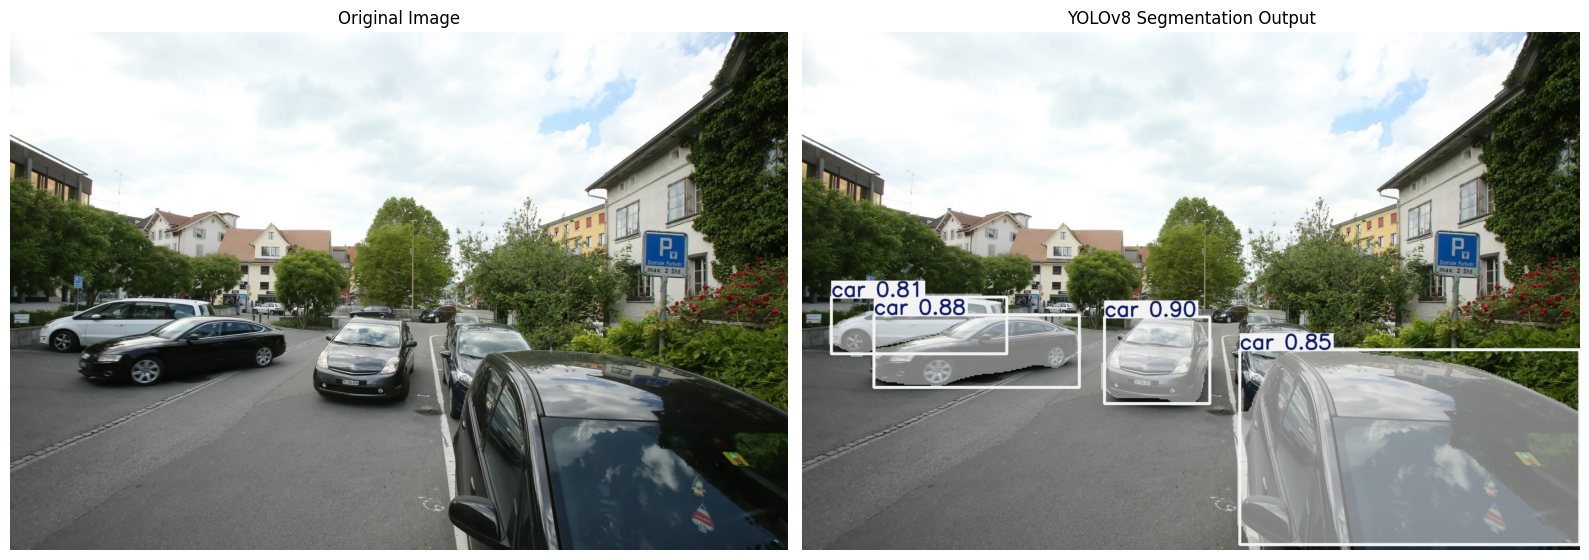

In [4]:
# Load original image
image = loader.load_image(image_path)

# Display original image and YOLO prediction side by side

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Original image
axes[0].imshow(RGBConverter.apply(image))
axes[0].set_title("Original Image")
axes[0].axis("off")

# YOLO segmentation output
axes[1].imshow(rendered_rgb)
axes[1].set_title("YOLOv8 Segmentation Output")
axes[1].axis("off")

plt.tight_layout()
plt.show()